# Additional Addis FTIR diagnostics

Six additional calculations and figures for the weekly discussion. Run this active source notebook from `research/ftir_hips_chem/` in the repository's uv environment. The executed copy is archived in `notebooks/archive/executed/`. Inputs are the completed September 10 analysis tables and corrected spectral caches. Seasons use `dry_feb`; exclusions follow the canonical registry. No model is refit or promoted, and the proposed Addis holdout is not scored.

Methods references: [SciPy paired bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html) describes keeping paired resamples aligned; here whole year-month clusters are resampled together. [scikit-learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) documents learning source components and projecting other observations. PCA input normalization is explicitly defined below.

In [1]:
import sys
sys.path.insert(0, './scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config import (
    SITES, PROCESSED_SITES_DIR, FILTER_DATA_PATH,
    AERONET_DATA_DIR, WEATHER_DATA_DIR, MAC_VALUE,
)
from outliers import (
    EXCLUDED_SAMPLES, MANUAL_OUTLIERS,
    apply_exclusion_flags, apply_threshold_flags,
    get_clean_data, print_exclusion_summary,
)
from data_matching import (
    load_aethalometer_data, load_filter_data,
    match_aeth_filter_data, match_all_parameters,
)
from etad_factors import load_etad_factor_contributions, match_etad_factors
from aeronet import load_aeronet, aeronet_dir, COLS as AERONET_COLS
from improve_io import load_improve_clean
from plotting import PlotConfig, crossplots, timeseries, distributions, comparisons
from plotting.utils import calculate_regression_stats

PlotConfig.set(sites='all', layout='individual', show_stats=True, show_1to1=True,
               figsize=(14.8, 5.6), font_size=18, title_size=22)

from pathlib import Path
from IPython.display import display
from plotting.ann_weekly_figures import AnnWeeklyFigures

from plotting.ann_weekly_diagnostics import AnnWeeklyDiagnostics


In [2]:
report = AnnWeeklyDiagnostics(Path.cwd().parents[1])
report.calculate()

Reselecting analogs: All Addis, 200 month resamples


Reselecting analogs: Dry (Oct-Feb), 200 month resamples


Reselecting analogs: Belg (Mar-May), 200 month resamples


Reselecting analogs: Kiremt (Jun-Sep), 200 month resamples


          season       candidate                  fit_id   n  n_months  n_boot  baseline_rmse  candidate_rmse  delta_rmse  delta_rmse_low  delta_rmse_high  baseline_mae  candidate_mae  delta_mae  delta_mae_low  delta_mae_high  baseline_bias  candidate_bias  delta_bias  delta_bias_low  delta_bias_high
   Dry (Oct-Feb) Season-specific    no_co2__Dry__Oct_Feb 105        16    4000       2.038466        3.145081    1.106615        1.023759         1.193852      1.962197       3.077673   1.115476       1.040272        1.192425      -1.962197       -3.077673   -1.115476       -1.192425        -1.040272
   Dry (Oct-Feb)       All-Addis       no_co2__All_Addis 105        16    4000       2.038466        2.886672    0.848205        0.746086         0.954454      1.962197       2.820895   0.858697       0.754486        0.965321      -1.962197       -2.820895   -0.858697       -0.965321        -0.754486
  Belg (Mar-May) Season-specific   no_co2__Belg__Mar_May  61         9    4000       1.728930 

## Paired comparison: same Addis filters

Each candidate is compared with the historical calibration on identical filters. Positive differences mean greater RMS discrepancy from HIPS Fabs/MAC. Error bars are 95% percentile intervals from 4,000 paired whole-month resamples. These are conditional, exploratory discrepancies, not chemical-EC validation errors.

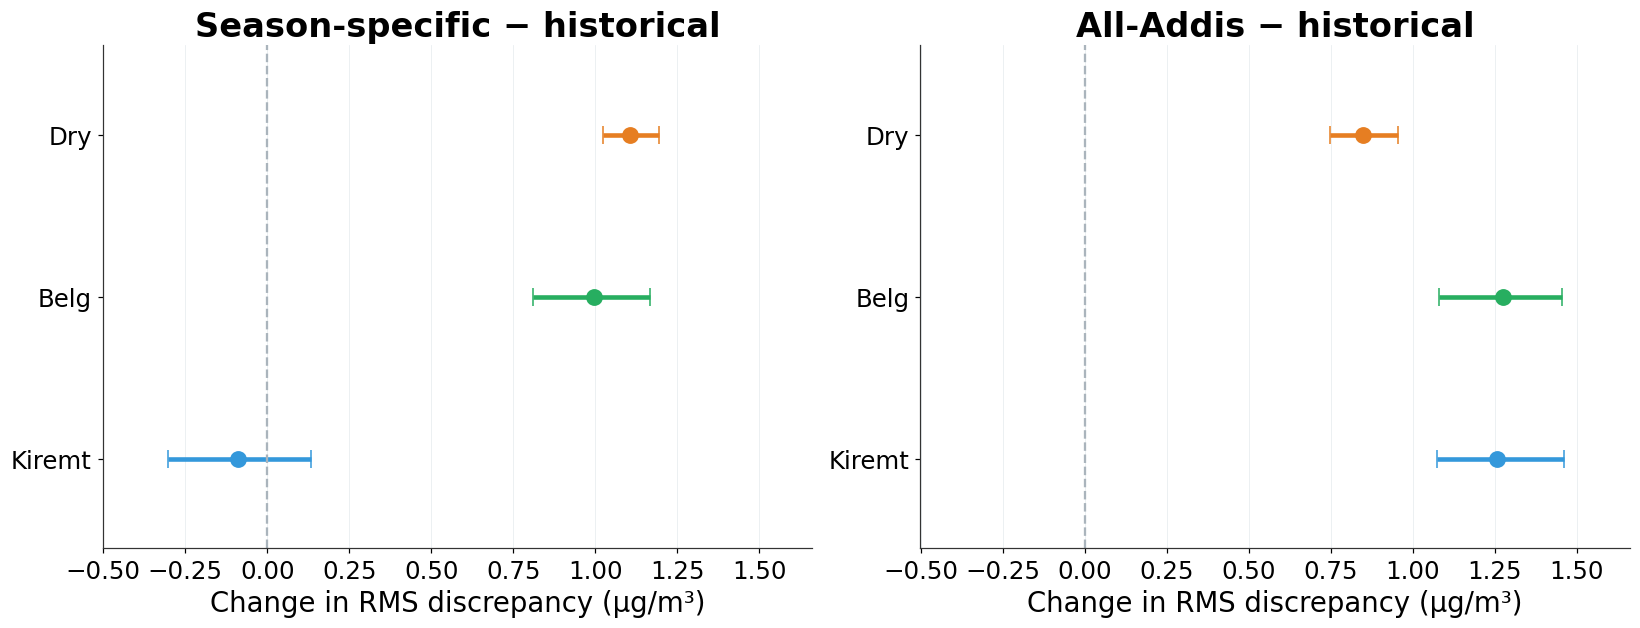

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/ann_weekly_20260910_diagnostics/slide_13.png


In [3]:
fig = report.paired_comparison()
png = report.save(fig, 13)
display(fig)
plt.close(fig)
print(png)

## Cross-season transfer

Each column uses the same Addis filters for all five calibration choices. Rows differ only in the already fitted calibration. The left panel measures agreement with the HIPS proxy; the right measures squared correlation. This distinguishes a model effect from season composition without treating correlation as accuracy.

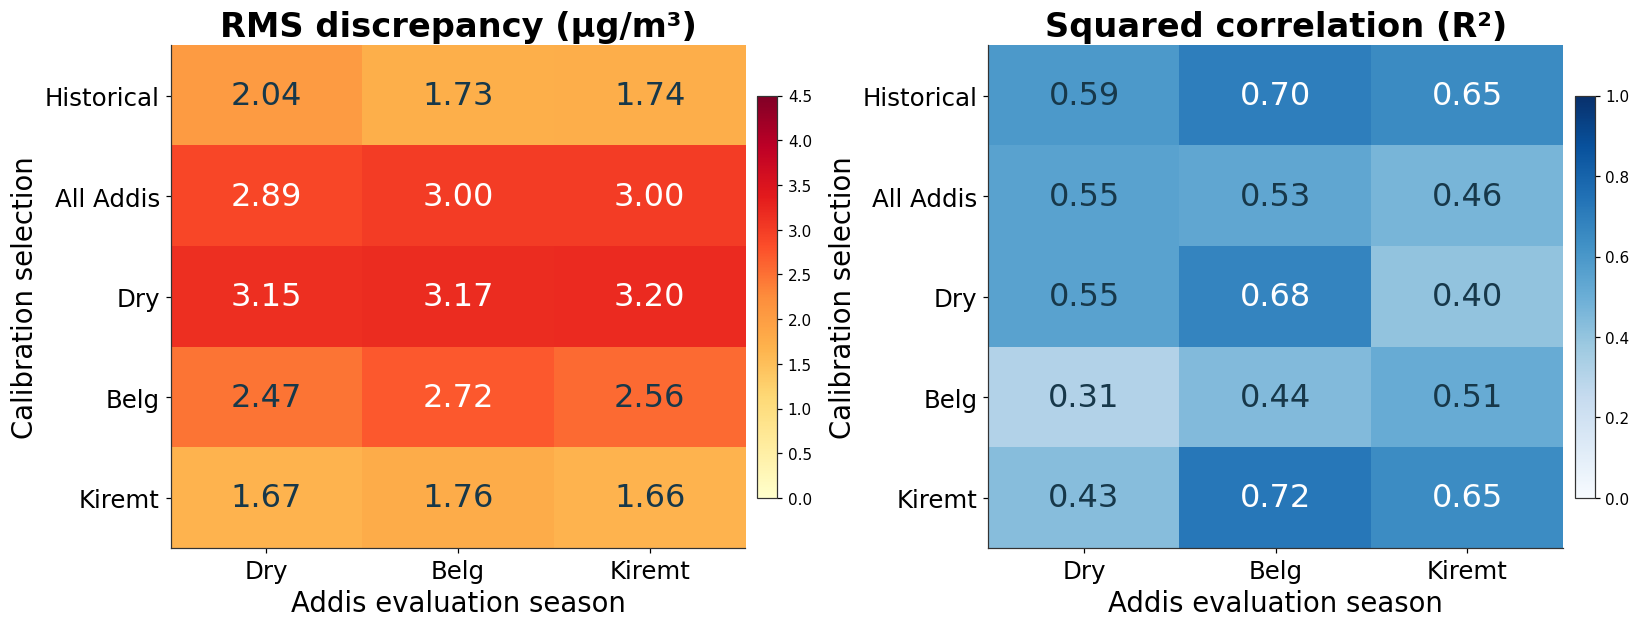

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/ann_weekly_20260910_diagnostics/slide_14.png


In [4]:
fig = report.transfer_heatmap()
png = report.save(fig, 14)
display(fig)
plt.close(fig)
print(png)

## Monthly discrepancy

Monthly mean differences are filter-weighted within each observed month. The season-specific series applies the corresponding seasonal model. Missing months break lines; month-level sample counts are saved. A pattern here is descriptive and does not establish a physical mechanism.

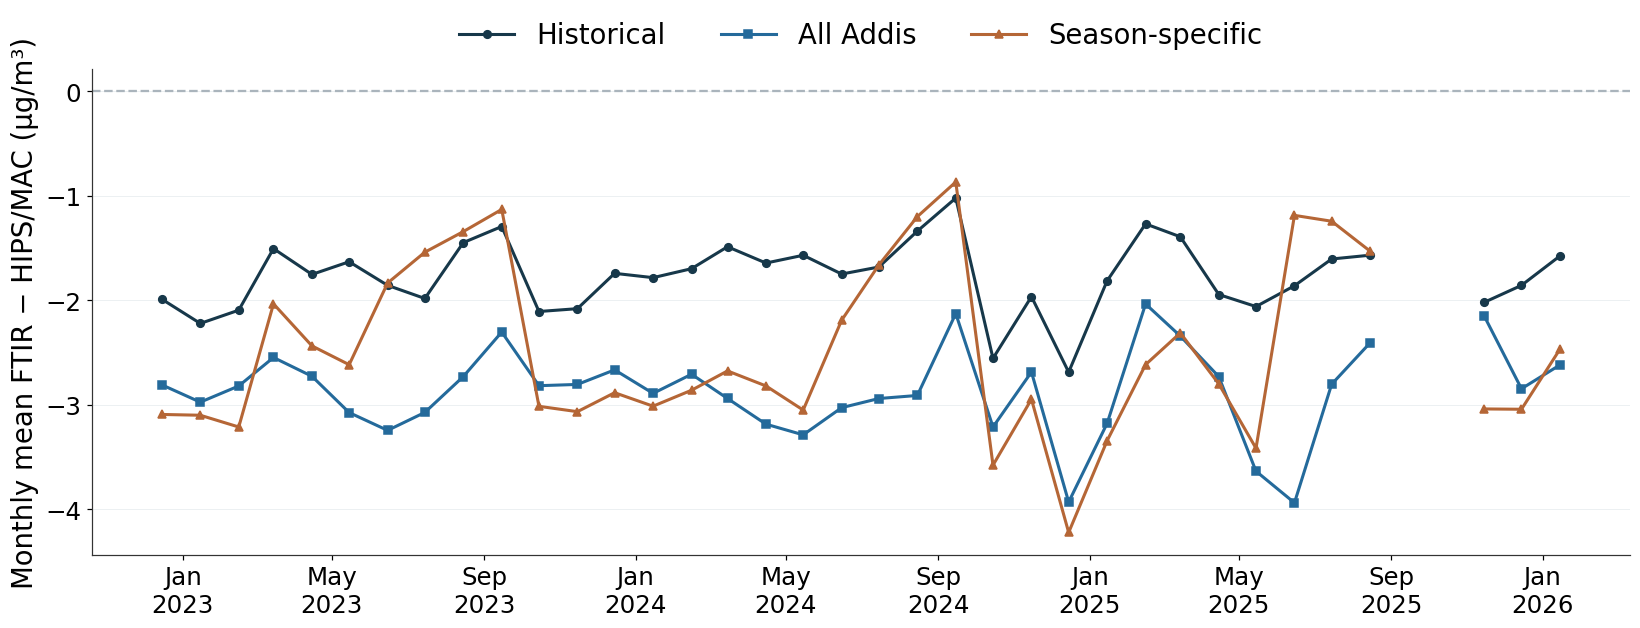

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/ann_weekly_20260910_diagnostics/slide_15.png


In [5]:
fig = report.monthly_bias()
png = report.save(fig, 15)
display(fig)
plt.close(fig)
print(png)

## Analog selection stability

For each target group, resample complete observed year-month blocks 200 times, recompute its median spectrum, and rerank all eligible source spectra using signed Pearson correlation with CO₂ excluded. Select 500 unique physical filters each time. The baseline must exactly match the original saved cohort. Boxes span quartiles; whiskers span the 5th–95th percentiles of resamples, not confidence intervals. The 80% line is a descriptive stability marker, not an acceptance standard.

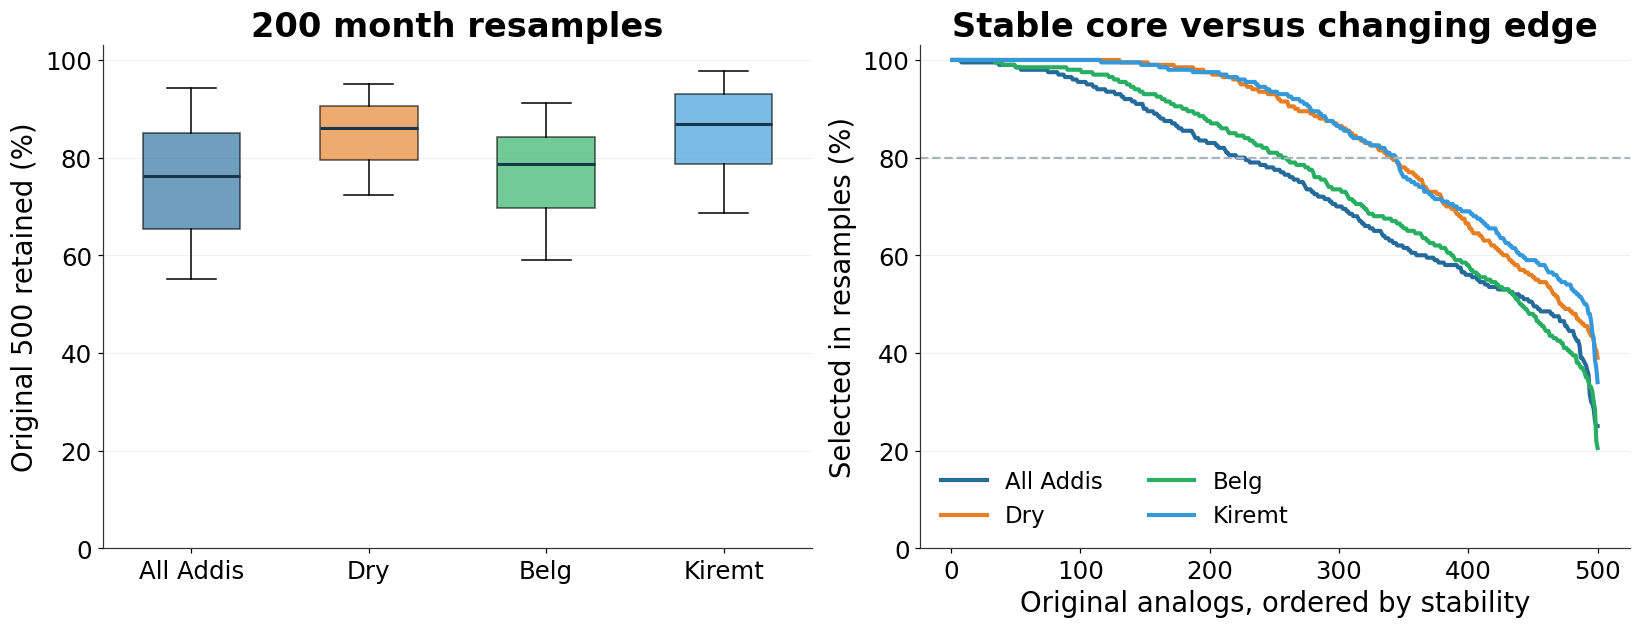

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/ann_weekly_20260910_diagnostics/slide_16.png


In [6]:
fig = report.stability_plot()
png = report.save(fig, 16)
display(fig)
plt.close(fig)
print(png)

## Spectral shape and reconstruction

Center and unit-normalize every spectrum over the retained channels as in Pearson matching. Fit a fixed ten-component PCA to all unique TOR-eligible IMPROVE filters and project Addis without refitting. The map shows only two PCs. The right panel counts Addis spectra whose ten-PC squared reconstruction residual exceeds the source 95th percentile. This is a descriptive source-relative threshold, not a calibrated rejection rule or a prediction-error bound. No chemical identities are assigned to PCs.

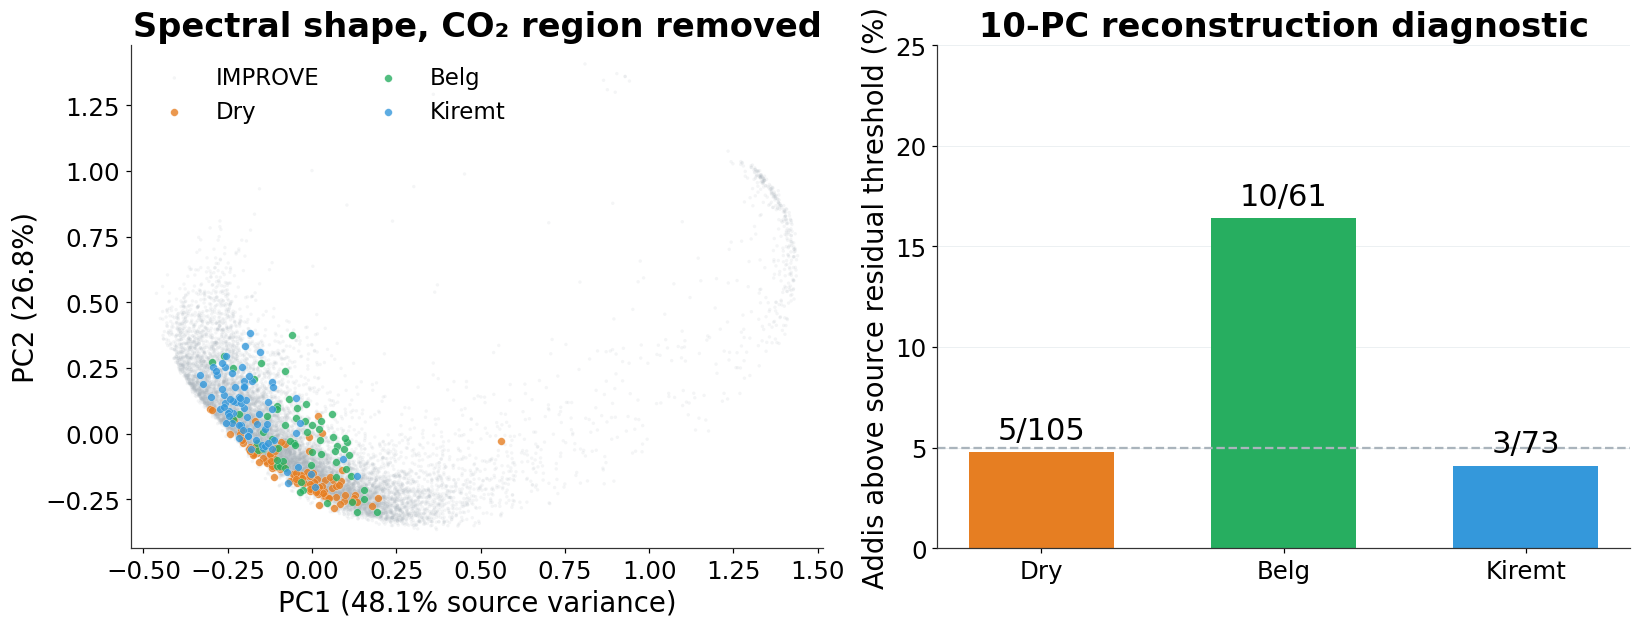

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/ann_weekly_20260910_diagnostics/slide_17.png


In [7]:
fig = report.shape_map()
png = report.save(fig, 17)
display(fig)
plt.close(fig)
print(png)

## Source-site concentration

Each primary cohort has 500 unique filters. Distinct site count is compared with the inverse-Simpson effective number of sites, 1/Σp², where p is a site's fraction of filters. This indicates concentration, not an effective independent sample size. The curve retains all source sites and the underlying CSV names each site.

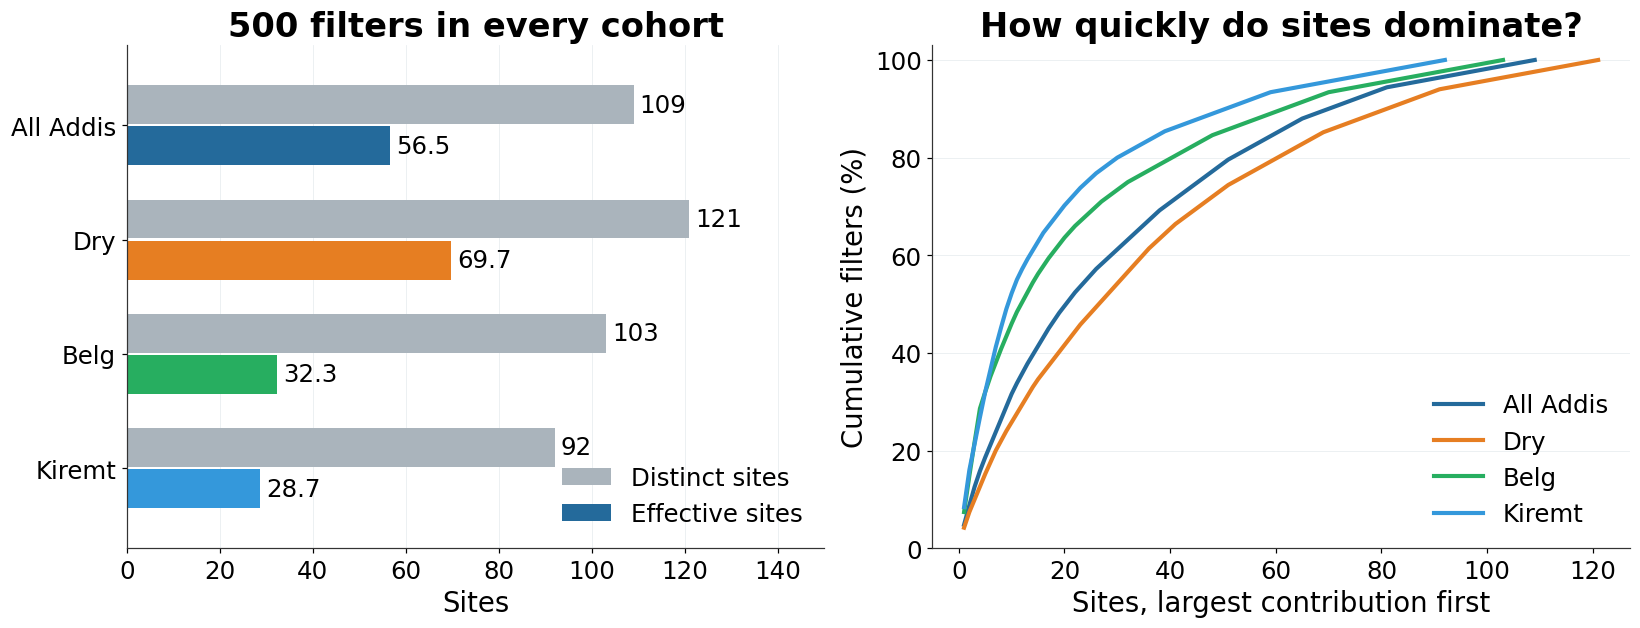

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/ann_weekly_20260910_diagnostics/slide_18.png


In [8]:
fig = report.diversity_plot()
png = report.save(fig, 18)
display(fig)
plt.close(fig)
print(png)